# Curvilinear-grid NetCDF files

Grids with 2-D latitude/longitude coordinate arrays (no single affine transform). These support inspection, plotting (via pcolormesh), retrieval, and variable mutation, but not affine polygon crop.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile

import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon

from pyramids.netcdf import NetCDF, UgridDataset
from pyramids.feature import FeatureCollection

DATA = Path('../../../../examples/data/netcdf/samples')

2026-06-18 15:00:45 | INFO | pyramids.base.config | Logging is configured.


## `cf__8v__1d3-2d3-3d1-4d1__curv-stag.nc`

ROMS ocean model output on a curvilinear, staggered (Arakawa-C) grid.

**Open the file and inspect the container**

In [2]:
nc = NetCDF.read_file(DATA / 'cf__8v__1d3-2d3-3d1-4d1__curv-stag.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\cf__8v__1d3-2d3-3d1-4d1__curv-stag.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [3]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

2026-06-18 15:00:46 | WARNING | pyramids.base.config.gdal | GDAL[1] Cannot find variable corresponding to coordinate hc


2026-06-18 15:00:46 | WARNING | pyramids.base.config.gdal | GDAL[1] Cannot find variable corresponding to coordinate Vtransform


2026-06-18 15:00:46 | WARNING | pyramids.base.config.gdal | GDAL[1] Cannot find variable corresponding to coordinate hc


2026-06-18 15:00:46 | WARNING | pyramids.base.config.gdal | GDAL[1] Cannot find variable corresponding to coordinate Vtransform


NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (4):
    eta_rho              size=191
    ocean_time           size=2
    s_rho                size=6
    xi_rho               size=371
  Variables (8):
    Cs_r dims=('/s_rho',) shape=(6,) dtype=float64
    h dims=('/eta_rho', '/xi_rho') shape=(191, 371) dtype=float64 unit='meter'
    lat_rho dims=('/eta_rho', '/xi_rho') shape=(191, 371) dtype=float64 unit='degree_north'
    lon_rho dims=('/eta_rho', '/xi_rho') shape=(191, 371) dtype=float64 unit='degree_east'
    ocean_time dims=('/ocean_time',) shape=(2,) dtype=float64 unit='seconds since 1970-01-01'
    s_rho dims=('/s_rho',) shape=(6,) dtype=float64
    salt dims=('/ocean_time', '/s_rho', '/eta_rho', '/xi_rho') shape=(2, 6, 191, 371) dtype=float32
    zeta dims=('/ocean_time', '/eta_rho', '/xi_rho') shape=(2, 191, 371) dtype=float32 unit='meter'
  Global attributes: Conventions, file, format, type, title, ... (34 total)


**Global attributes**

In [4]:
nc.global_attributes

{'Conventions': 'CF-1.4',
 'file': '../output_20yr_obc/2001/ocean_his_0015.nc',
 'format': 'netCDF-4/HDF5 file',
 'type': 'ROMS/TOMS history file',
 'title': 'TXLA ROMS hindcast run with dyes and oxygen',
 'rst_file': '../output_20yr_obc/2001/ocean_rst.nc',
 'his_base': '../output_20yr_obc/2001/ocean_his',
 'avg_base': '../output_20yr_obc/2001/ocean_avg',
 'dia_base': '../output_20yr_obc/2001/ocean_dia',
 'sta_file': 'ocean_sta.nc',
 'grd_file': '../inputs/grd/txla2_grd_v4_test_lcut_hglo_wtype.nc',
 'ini_file': '../output_20yr_obc/2000/ocean_rst.nc',
 'frc_file_01': '../inputs/2001/txla_bulk_ERAI_2001.nc',
 'frc_file_02': '../inputs/2001/txla_flx_ICOADS_AVHRR_SST_2001.nc, ../inputs/2002/txla_flx_ICOADS_AVHRR_SST_2002.nc',
 'bry_file_01': '../inputs/2001/txla2_bry_2001_glo_ReAna_v4_o2woa.nc, ../inputs/2002/txla2_bry_2002_glo_ReAna_v4_o2woa.nc',
 'clm_file_01': '../inputs/2001/txla2_clm_2001_01_glo_ReAna_v4_o2woa.nc, ../inputs/2001/txla2_clm_2001_02_glo_ReAna_v4_o2woa.nc, ../inputs/2001/

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

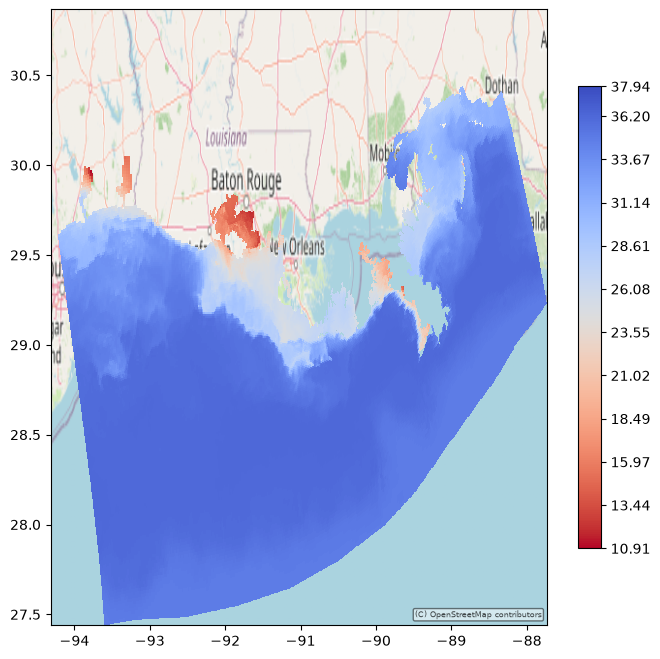

In [5]:
nc.plot(variable='salt', basemap=True)

**Retrieve the underlying data**

In [6]:
var = nc.get_variable('salt')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (12, 191, 371)
min / mean / max: 6.549163818359375 inf 9.999999933815813e+36


C:\python-environments\pixi\envs\pyramids-gis-17387402636982928789\envs\dev\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


**Add a variable** — derive a 2-D field and append it as a new variable

In [7]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=(0.0, 1.0, 0.0, 0.0, 0.0, -1.0), epsg=var.epsg or 4326,
    variable_name='salt_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'salt_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['Cs_r', 'h', 'lat_rho', 'lon_rho', 'salt', 'salt_slice0', 'zeta']


**Remove a variable**

In [8]:
nc.remove_variable('salt_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['Cs_r', 'h', 'lat_rho', 'lon_rho', 'salt', 'zeta']


> **Why no polygon crop here?** `crop` is an *affine* warp: it needs a regular grid whose pixels map to lon/lat through a single geotransform. This file is **curvilinear** — its coordinates are 2-D arrays (`lat(y, x)`, `lon(y, x)`), so there is no single cell size or affine transform to clip against, and a polygon cutline can't be applied. To subset such a grid you index it in its native (y, x) space. Polygon cropping is demonstrated on the rectilinear grids in `01-gridded-cf` / `02-gridded-coards` / `03-packed-int16`.

**Save the container to a new NetCDF file**

In [9]:
out = work / 'saved.nc'
nc.to_file(str(out))
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True


## `none__4v__1d1-2d2-3d1__curv.nc`

WRF/RASM air temperature on a curvilinear grid (2-D xc/yc coordinates).

**Open the file and inspect the container**

In [10]:
nc = NetCDF.read_file(DATA / 'none__4v__1d1-2d2-3d1__curv.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\none__4v__1d1-2d2-3d1__curv.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [11]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (3):
    time                 size=6
    x                    size=275
    y                    size=205
  Variables (4):
    Tair dims=('/time', '/y', '/x') shape=(6, 205, 275) dtype=float64 unit='C'
    time dims=('/time',) shape=(6,) dtype=float64 unit='days since 0001-01-01'
    xc dims=('/y', '/x') shape=(205, 275) dtype=float64 unit='degrees_east'
    yc dims=('/y', '/x') shape=(205, 275) dtype=float64 unit='degrees_north'
  Global attributes: title, institution, source, output_frequency, output_mode, ... (11 total)


**Global attributes**

In [12]:
nc.global_attributes

{'title': '/workspace/jhamman/processed/R1002RBRxaaa01a/lnd/temp/R1002RBRxaaa01a.vic.ha.1979-09-01.nc',
 'institution': 'U.W.',
 'source': 'RACM R1002RBRxaaa01a',
 'output_frequency': 'daily',
 'output_mode': 'averaged',
 'convention': 'CF-1.4',
 'references': 'Based on the initial model of Liang et al., 1994, JGR, 99, 14,415- 14,429.',
 'comment': 'Output from the Variable Infiltration Capacity (VIC) model.',
 'nco_openmp_thread_number': 1,
 'NCO': 'netCDF Operators version 4.7.9 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)',
 'history': 'Fri Aug  7 17:57:38 2020: ncatted -a bounds,,d,, rasm.nc\nTue Dec 27 14:15:22 2016: ncatted -a dimensions,,d,, rasm.nc rasm.nc\nTue Dec 27 13:38:40 2016: ncks -3 rasm.nc rasm.nc\nhistory deleted for brevity'}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

C:\python-environments\pixi\envs\pyramids-gis-17387402636982928789\envs\dev\Lib\site-packages\cleopatra\array_glyph.py:1461: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


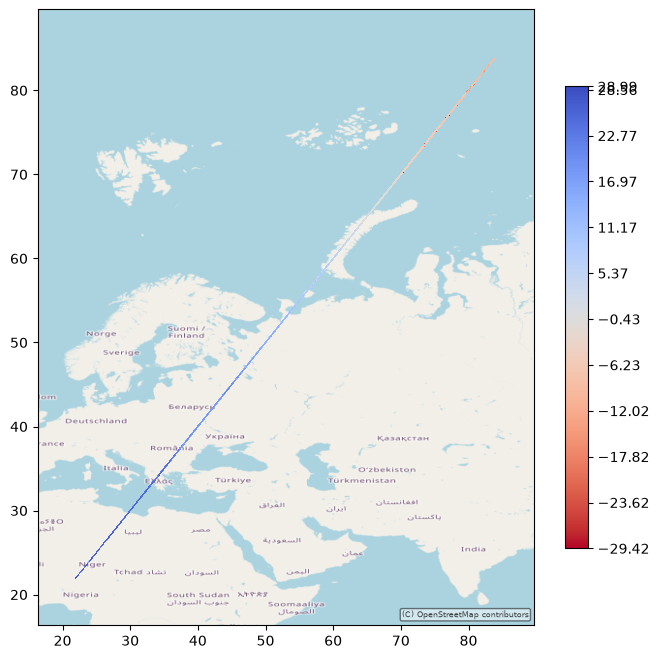

In [13]:
nc.plot(variable='Tair', basemap=True)

**Retrieve the underlying data**

In [14]:
var = nc.get_variable('Tair')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (6, 205, 275)
min / mean / max: -45.14314058601594 5.372144206290461e+36 9.969209968386869e+36


**Add a variable** — derive a 2-D field and append it as a new variable

In [15]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=(0.0, 1.0, 0.0, 0.0, 0.0, -1.0), epsg=var.epsg or 4326,
    variable_name='Tair_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'Tair_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['Tair', 'Tair_slice0', 'xc', 'yc']


**Remove a variable**

In [16]:
nc.remove_variable('Tair_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['Tair', 'xc', 'yc']


> **Why no polygon crop here?** `crop` is an *affine* warp: it needs a regular grid whose pixels map to lon/lat through a single geotransform. This file is **curvilinear** — its coordinates are 2-D arrays (`lat(y, x)`, `lon(y, x)`), so there is no single cell size or affine transform to clip against, and a polygon cutline can't be applied. To subset such a grid you index it in its native (y, x) space. Polygon cropping is demonstrated on the rectilinear grids in `01-gridded-cf` / `02-gridded-coards` / `03-packed-int16`.

**Save the container to a new NetCDF file**

In [17]:
out = work / 'saved.nc'
nc.to_file(str(out))
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True


## `none__5v__1d2-2d2-3d1__curv.nc`

Satellite IMAGE product with 2-D latitude/longitude and string metadata variables.

**Open the file and inspect the container**

In [18]:
nc = NetCDF.read_file(DATA / 'none__5v__1d2-2d2-3d1__curv.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\none__5v__1d2-2d2-3d1__curv.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [19]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (4):
    auditCount           size=1
    bands                size=5
    elems                size=640
    lines                size=480
  Variables (5):
    auditTrail dims=('/auditCount',) shape=(1,) dtype=unknown
    bands dims=('/bands',) shape=(5,) dtype=int32
    data dims=('/bands', '/lines', '/elems') shape=(5, 480, 640) dtype=float32 unit='unitless'
    latitude dims=('/lines', '/elems') shape=(480, 640) dtype=float32 unit='degrees'
    longitude dims=('/lines', '/elems') shape=(480, 640) dtype=float32 unit='degrees'
  Global attributes: 


**Global attributes**

In [20]:
nc.global_attributes

{}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

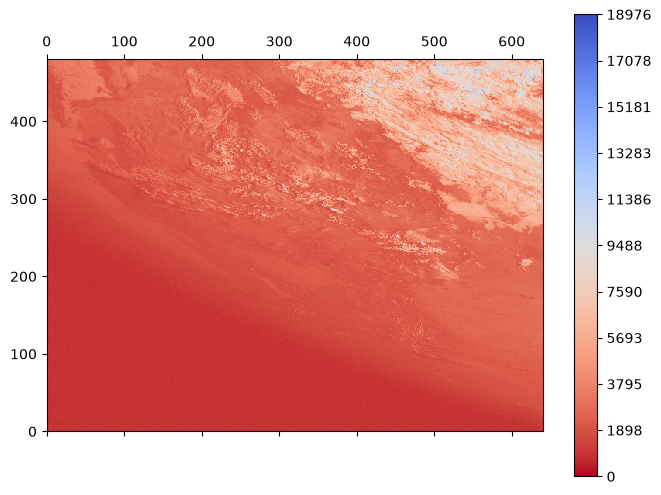

In [21]:
nc.plot(variable='data')

**Retrieve the underlying data**

In [22]:
var = nc.get_variable('data')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (5, 480, 640)
min / mean / max: 0.0 6867.66015625 23328.0


**Add a variable** — derive a 2-D field and append it as a new variable

In [23]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=(0.0, 1.0, 0.0, 0.0, 0.0, -1.0), epsg=var.epsg or 4326,
    variable_name='data_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'data_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['auditTrail', 'data', 'data_slice0', 'latitude', 'longitude']


**Remove a variable**

In [24]:
nc.remove_variable('data_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['auditTrail', 'data', 'latitude', 'longitude']


> **Why no polygon crop here?** `crop` is an *affine* warp: it needs a regular grid whose pixels map to lon/lat through a single geotransform. This file is **curvilinear** — its coordinates are 2-D arrays (`lat(y, x)`, `lon(y, x)`), so there is no single cell size or affine transform to clip against, and a polygon cutline can't be applied. To subset such a grid you index it in its native (y, x) space. Polygon cropping is demonstrated on the rectilinear grids in `01-gridded-cf` / `02-gridded-coards` / `03-packed-int16`.

**Save the container to a new NetCDF file**

In [25]:
out = work / 'saved.nc'
nc.to_file(str(out))
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True
